In [1]:
from pathlib import Path
import pandas as pd

# Dataset locations
ROOT = Path.cwd()
TRAIN_DIR = ROOT / "train" / "train"
TEST_DIR = ROOT / "test" / "test"

# Load CSV files
train_df = pd.read_csv(ROOT / "train_labels.csv", dtype={"image_id": str}) 

print("Training data:", train_df.shape)
print(train_df.head())

Training data: (63660, 2)
  image_id     class
0    00001    DogEye
1    00002  DogMouth
2    00003   DogFace
3    00004   DogNose
4    00005   DogNose


Missing Values:
 image_id    0
class       0
dtype: int64

Duplicate image IDs: 0

Unexpected classes: set()

Class distribtuion:
class
CatEye      13884
DogEye      11580
CatNose      6942
CatFace      6942
CatMouth     6942
DogMouth     5790
DogFace      5790
DogNose      5790
Name: count, dtype: int64

Total Images: 63660


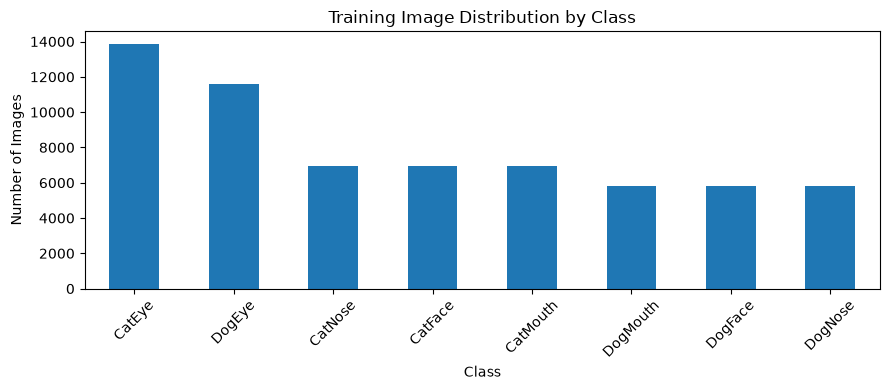

In [2]:
# data quality
print("Missing Values:\n", train_df.isna().sum())
print("\nDuplicate image IDs:", train_df["image_id"].duplicated().sum())

# validate class names
classes = ["CatEye", "DogEye", "CatFace", "DogFace", "CatMouth", "DogMouth", "CatNose", "DogNose"]

print("\nUnexpected classes:", set(train_df["class"].dropna()) - set(classes))

# Class distribution
class_counts = train_df["class"].value_counts()

print("\nClass distribtuion:")
print(class_counts)
print("\nTotal Images:", len(train_df))

import matplotlib.pyplot as plt

class_counts.plot(kind="bar", figsize=(9, 4))
plt.title("Training Image Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [3]:
# Find training images without loading
image_files = [p for p in TRAIN_DIR.iterdir() if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}]

# Compare ids without leading zeros
csv_ids = {x.lstrip("0") or "0" for x in train_df["image_id"]}
file_ids = {p.stem.lstrip("0") or "0" for p in image_files}

#check image consistency
missing_images = csv_ids - file_ids
extra_images = file_ids - csv_ids

print("CSV records:", len(train_df))
print("Image files:", len(image_files))
print("Missing images:", len(missing_images))
print("Unlabelled images:", len(extra_images))
print("Duplicate filename IDs:", len(image_files) - len(file_ids))

print("\nExample filenames:", [p.name for p in image_files[:5]])
print("Missing ID examples:", list(missing_images)[:5])

CSV records: 63660
Image files: 63660
Missing images: 0
Unlabelled images: 0
Duplicate filename IDs: 0

Example filenames: ['00001.jpg', '00002.jpg', '00003.jpg', '00004.jpg', '00005.jpg']
Missing ID examples: []


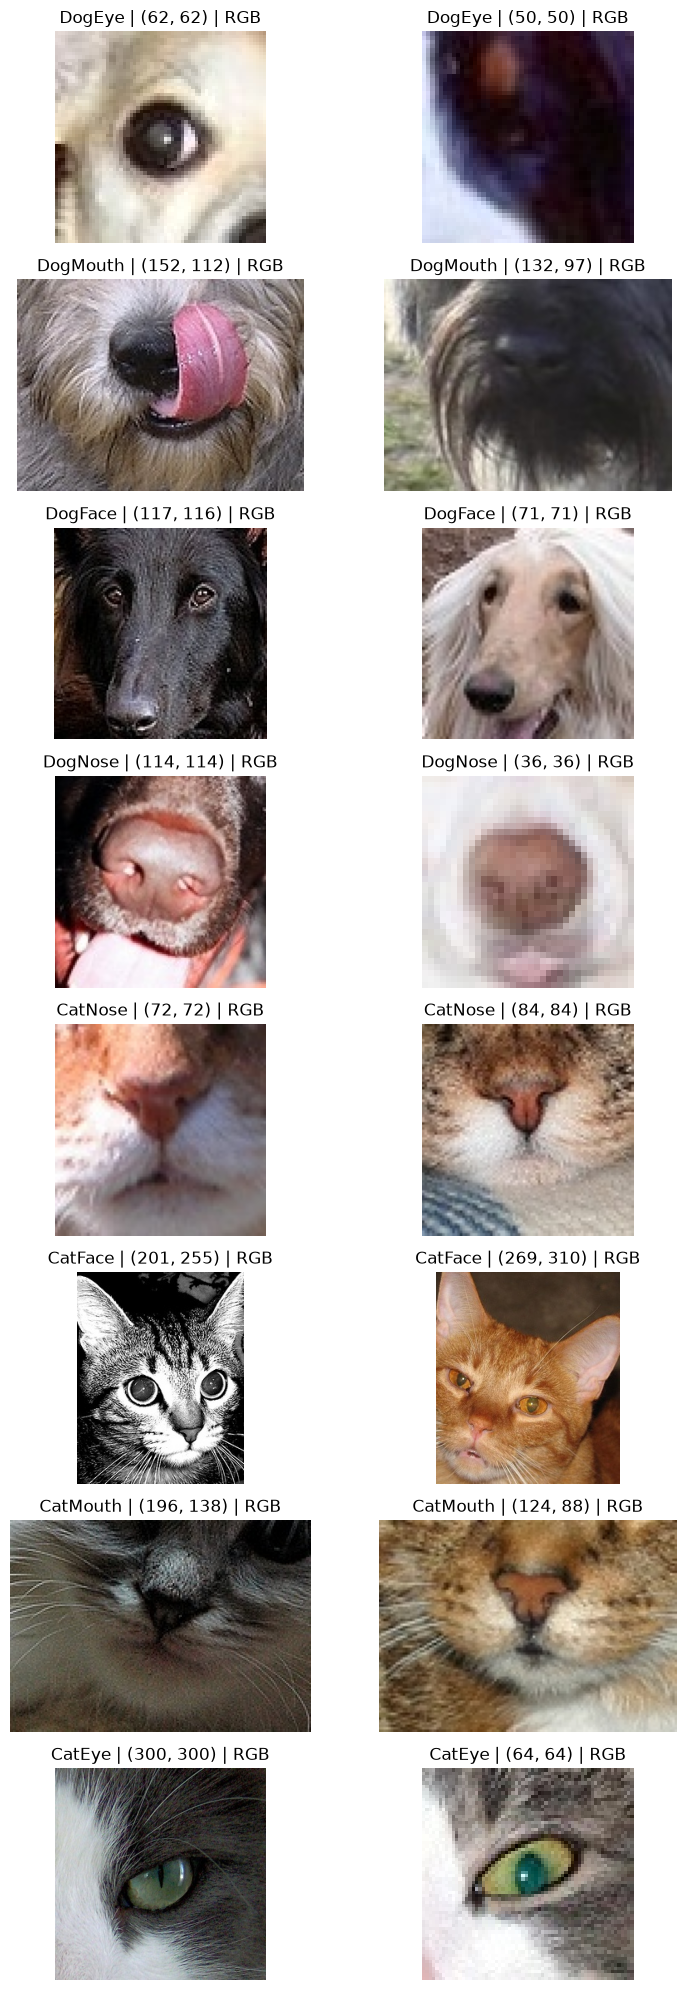

In [4]:
from PIL import Image

# Sample two images from each class
samples = train_df.groupby("class", sort=False).sample(n=2, random_state=42)

# Display samples 8x2
fig, axes = plt.subplots(8,2,figsize=(8,20))

for i, (_, row) in enumerate(samples.iterrows()):
    image_path = TRAIN_DIR / f"{row['image_id']}.jpg"

    with Image.open(image_path) as img:
        axes.flat[i].imshow(img)
        axes.flat[i].set_title(f"{row['class']} | {img.size} | {img.mode}")

    axes.flat[i].axis("off")

plt.tight_layout()
plt.show()

In [5]:
from collections import Counter
from PIL import Image

# Track image properties
image_sizes = Counter()
image_modes = Counter()
image_formats = Counter()
corrupt_images = []

# Inspect each training image
for i, image_id in enumerate(train_df["image_id"], 1):
    image_path = TRAIN_DIR / f"{image_id}.jpg"

    try:
        with Image.open(image_path) as img:
            img.load()  # Check that image pixels can be decoded
            image_sizes[img.size] += 1
            image_modes[img.mode] += 1
            image_formats[img.format] += 1

    except (OSError, ValueError) as e:
        corrupt_images.append((image_id, str(e)))

    if i % 10000 == 0:
        print(f"Checked {i:,} images...")

# Display results
print("\nUnique image dimensions:", len(image_sizes))
print("Most common dimensions:", image_sizes.most_common(10))
print("Colour modes:", image_modes)
print("File formats:", image_formats)

print("\nWidth range:", min(w for w, h in image_sizes),
      "to", max(w for w, h in image_sizes))

print("Height range:", min(h for w, h in image_sizes),
      "to", max(h for w, h in image_sizes))

print("\nCorrupted images:", len(corrupt_images))
print("Examples:", corrupt_images[:5])

Checked 10,000 images...
Checked 20,000 images...
Checked 30,000 images...
Checked 40,000 images...
Checked 50,000 images...
Checked 60,000 images...

Unique image dimensions: 7861
Most common dimensions: [((40, 40), 1062), ((48, 48), 1051), ((42, 42), 1050), ((38, 38), 1002), ((44, 44), 1002), ((46, 46), 985), ((34, 34), 978), ((36, 36), 963), ((54, 54), 952), ((52, 52), 928)]
Colour modes: Counter({'RGB': 63660})
File formats: Counter({'JPEG': 63660})

Width range: 4 to 2219
Height range: 4 to 2219

Corrupted images: 0
Examples: []


Shortest-side percentiles:
[   4.     50.     78.    126.    205.    268.05 2219.  ]

Percentage of images below:
32px: 6.5%
64px: 37.2%
128px: 75.5%
224px: 91.8%

Square images: 65.5%


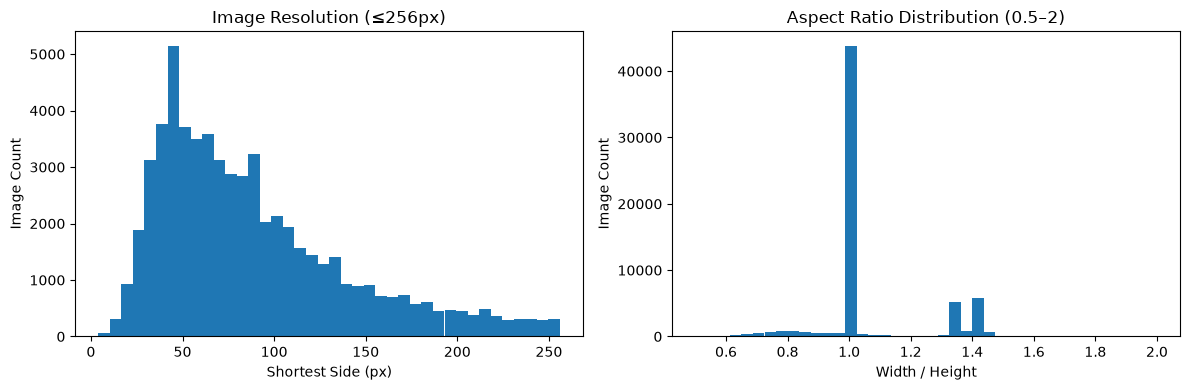

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Convert dimension counts into a DataFrame
size_df = pd.DataFrame(
    [(w, h, count) for (w, h), count in image_sizes.items()],
    columns=["width", "height", "count"]
)

# Calculate shortest side and aspect ratio
size_df["short_side"] = size_df[["width", "height"]].min(axis=1)
size_df["aspect_ratio"] = size_df["width"] / size_df["height"]

# Reconstruct distributions using image frequencies
short_sides = np.repeat(size_df["short_side"], size_df["count"])
aspect_ratios = np.repeat(size_df["aspect_ratio"], size_df["count"])

# Resolution statistics
print("Shortest-side percentiles:")
print(np.percentile(short_sides, [0, 25, 50, 75, 90, 95, 100]))

print("\nPercentage of images below:")
for limit in [32, 64, 128, 224]:
    print(f"{limit}px: {(short_sides < limit).mean():.1%}")

print("\nSquare images:", f"{(aspect_ratios == 1).mean():.1%}")

# Visualise distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(short_sides[short_sides <= 256], bins=40)
axes[0].set(title="Image Resolution (≤256px)", xlabel="Shortest Side (px)", ylabel="Image Count")

axes[1].hist(aspect_ratios[(aspect_ratios >= 0.5) & (aspect_ratios <= 2)], bins=40)
axes[1].set(title="Aspect Ratio Distribution (0.5–2)", xlabel="Width / Height", ylabel="Image Count")

plt.tight_layout()
plt.show()

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# Reproducible training/validation split
train_data, val_data = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df["class"]
)

# Class encoding
class_names = sorted(train_df["class"].unique())
class_to_idx = {name: i for i, name in enumerate(class_names)}

# Fixed-resolution preprocessing
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Custom dataset to match image IDs with labels
class AnimalDataset(Dataset):
    def __init__(self, data):
        self.data = data.reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        with Image.open(TRAIN_DIR / f"{row['image_id']}.jpg") as img:
            image = transform(img.convert("RGB"))

        label = class_to_idx[row["class"]]
        return image, label

# Create data loaders
train_loader = DataLoader(AnimalDataset(train_data), batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(AnimalDataset(val_data), batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

print("Training images:", len(train_data))
print("Validation images:", len(val_data))
print("Classes:", class_names)

Training images: 50928
Validation images: 12732
Classes: ['CatEye', 'CatFace', 'CatMouth', 'CatNose', 'DogEye', 'DogFace', 'DogMouth', 'DogNose']


In [8]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Linear(128, 8)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

torch.manual_seed(42)
model = CNN().to(device)

print("Device:", device)
print("Parameters:", sum(p.numel() for p in model.parameters()))

Device: cuda
Parameters: 94280


In [11]:
from image_dataset import AnimalDatasetParallel

# Memory-efficient training configuration
BATCH_SIZE = 64
NUM_WORKERS = 2

train_loader_fast = DataLoader(
    AnimalDatasetParallel(train_data, TRAIN_DIR, class_to_idx, transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=1
)

val_loader_fast = DataLoader(
    AnimalDatasetParallel(val_data, TRAIN_DIR, class_to_idx, transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=1
)

print("Batch size:", BATCH_SIZE)
print("CPU workers:", NUM_WORKERS)
print("Persistent workers: Disabled")

import time
import torch
import torch.nn as nn
from torch.amp import autocast, GradScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Fresh model, same architecture as the original baseline
torch.manual_seed(42)
model_fast = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer_fast = torch.optim.Adam(model_fast.parameters(), lr=0.001)
scaler = GradScaler("cuda", enabled=device.type == "cuda")

best_acc = 0
history_fast = {"train_acc": [], "val_acc": [], "epoch_time": []}

for epoch in range(8):
    start = time.perf_counter()
    model_fast.train()
    train_correct = 0

    for images, labels in train_loader_fast:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer_fast.zero_grad(set_to_none=True)

        with autocast("cuda", dtype=torch.float16, enabled=device.type == "cuda"):
            outputs = model_fast(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer_fast)
        scaler.update()

        train_correct += (outputs.argmax(1) == labels).sum().item()

    model_fast.eval()
    val_correct = 0

    with torch.no_grad():
        for images, labels in val_loader_fast:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast("cuda", dtype=torch.float16, enabled=device.type == "cuda"):
                outputs = model_fast(images)

            val_correct += (outputs.argmax(1) == labels).sum().item()

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start
    train_acc = train_correct / len(train_data)
    val_acc = val_correct / len(val_data)

    history_fast["train_acc"].append(train_acc)
    history_fast["val_acc"].append(val_acc)
    history_fast["epoch_time"].append(elapsed)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model_fast.state_dict(), "cnn_128_fp16_batch64.pt")

    print(f"Epoch {epoch+1}/8 | Train: {train_acc:.2%} | "
          f"Validation: {val_acc:.2%} | Time: {elapsed:.2f}s")

print(f"\nBest validation accuracy: {best_acc:.2%}")
print(f"Total training time: {sum(history_fast['epoch_time']):.2f}s")

Batch size: 64
CPU workers: 2
Persistent workers: Disabled
Epoch 1/8 | Train: 27.56% | Validation: 37.84% | Time: 29.54s
Epoch 2/8 | Train: 46.43% | Validation: 51.54% | Time: 28.92s
Epoch 3/8 | Train: 56.45% | Validation: 56.27% | Time: 28.89s
Epoch 4/8 | Train: 61.64% | Validation: 64.63% | Time: 28.72s
Epoch 5/8 | Train: 65.74% | Validation: 67.69% | Time: 28.99s
Epoch 6/8 | Train: 68.73% | Validation: 69.97% | Time: 28.99s
Epoch 7/8 | Train: 71.01% | Validation: 70.27% | Time: 29.10s
Epoch 8/8 | Train: 73.32% | Validation: 72.54% | Time: 29.28s

Best validation accuracy: 72.54%
Total training time: 232.43s


              precision    recall  f1-score   support

      CatEye      0.849     0.794     0.821      2777
     CatFace      0.826     0.880     0.852      1388
    CatMouth      0.808     0.691     0.745      1388
     CatNose      0.864     0.514     0.645      1389
      DogEye      0.603     0.750     0.669      2316
     DogFace      0.697     0.687     0.692      1158
    DogMouth      0.764     0.599     0.672      1158
     DogNose      0.531     0.785     0.633      1158

    accuracy                          0.725     12732
   macro avg      0.743     0.713     0.716     12732
weighted avg      0.749     0.725     0.727     12732



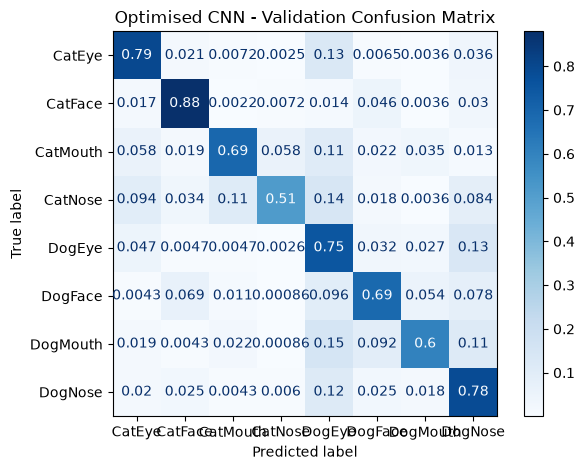

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Load best optimised model
model_fast.load_state_dict(torch.load(
    "cnn_128_fp16_batch64.pt", map_location=device, weights_only=True
))
model_fast.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in val_loader_fast:
        with autocast("cuda", dtype=torch.float16):
            outputs = model_fast(images.to(device))

        y_true.extend(labels.tolist())
        y_pred.extend(outputs.argmax(1).cpu().tolist())

# Per-class precision, recall and F1-score
print(classification_report(
    y_true, y_pred, target_names=class_names, digits=3
))

# Normalised confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=class_names,
    normalize="true",
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Optimised CNN - Validation Confusion Matrix")
plt.tight_layout()
plt.show()